# 01 — Exploration de la potabilité

Objectif : auditer `water_potability.csv` avant modélisation. Aucune imputation globale afin d’éviter la fuite de données.

## 1. Configuration

In [1]:
from pathlib import Path
import sys, warnings
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))
DATA_RAW=PROJECT_ROOT/"data"/"raw"; DATA_PROCESSED=PROJECT_ROOT/"data"/"processed"
FIGURES=PROJECT_ROOT/"reports"/"figures"; RESULTS=PROJECT_ROOT/"reports"/"results"; MODELS=PROJECT_ROOT/"models"
for p in [DATA_PROCESSED,FIGURES,RESULTS,MODELS]: p.mkdir(parents=True,exist_ok=True)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
RANDOM_STATE=42
pd.set_option("display.max_columns",100)

In [2]:
from src.data_cleaning import load_potability,basic_cleaning,data_quality_report,save_processed

## 2. Chargement

In [3]:
df_raw=load_potability(DATA_RAW/"water_potability.csv")
print("Dimensions :",df_raw.shape)
display(df_raw.head())

Dimensions : (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## 3. Structure et types

In [4]:
display(pd.DataFrame({"colonne":df_raw.columns,"dtype":df_raw.dtypes.astype(str).values}))

,colonne,dtype
0,ph,float64
1,Hardness,float64
2,Solids,float64
3,Chloramines,float64
4,Sulfate,float64
5,Conductivity,float64
6,Organic_carbon,float64
7,Trihalomethanes,float64
8,Turbidity,float64
9,Potability,int64


## 4. Qualité des données

In [5]:
display(data_quality_report(df_raw))
print("Doublons :",df_raw.duplicated().sum())

,dtype,missing_n,missing_pct,n_unique
ph,float64,491,14.99,2785
Hardness,float64,0,0.00,3276
Solids,float64,0,0.00,3276
Chloramines,float64,0,0.00,3276
Sulfate,float64,781,23.84,2495
Conductivity,float64,0,0.00,3276
Organic_carbon,float64,0,0.00,3276
Trihalomethanes,float64,162,4.95,3114
Turbidity,float64,0,0.00,3276
Potability,int64,0,0.00,2


Doublons : 0


## 5. Valeurs manquantes

,manquants
Sulfate,781
ph,491
Trihalomethanes,162


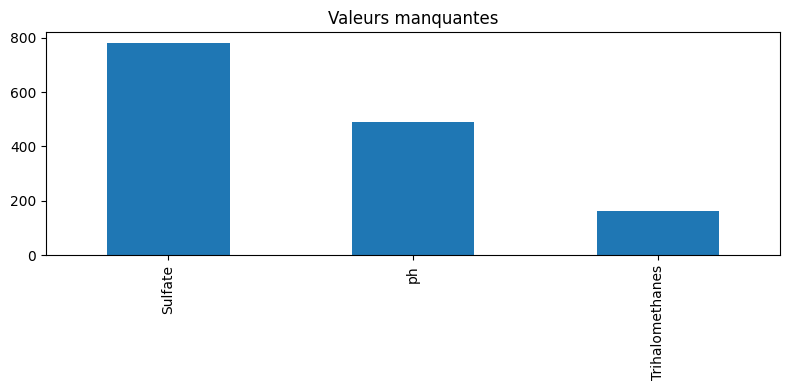

In [6]:
m=df_raw.isna().sum().sort_values(ascending=False); display(m[m>0].to_frame("manquants"))
if (m>0).any(): m[m>0].plot.bar(figsize=(8,4),title="Valeurs manquantes"); plt.tight_layout(); plt.show()

## 6. Nettoyage minimal

In [7]:
df=basic_cleaning(df_raw,target="Potability")
print(df.shape)

(3276, 10)


## 7. Cible Potability

,effectif,pourcentage
Potability,,
0,1998,60.99
1,1278,39.01


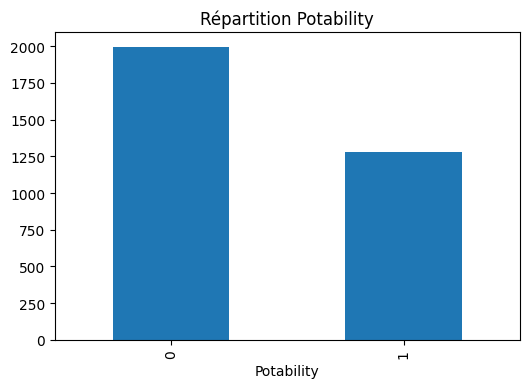

In [8]:
counts=df["Potability"].value_counts().sort_index(); pct=(100*df["Potability"].value_counts(normalize=True).sort_index()).round(2)
display(pd.DataFrame({"effectif":counts,"pourcentage":pct}))
counts.plot.bar(figsize=(6,4),title="Répartition Potability"); plt.show()

## 8. Statistiques descriptives

In [9]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


## 9. Distributions

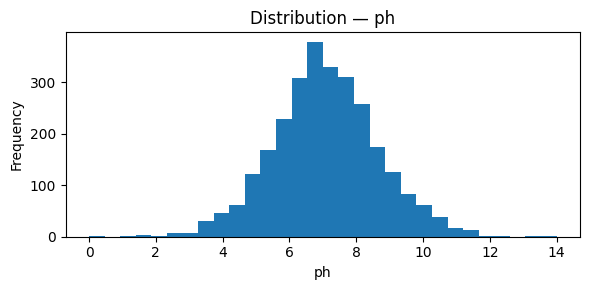

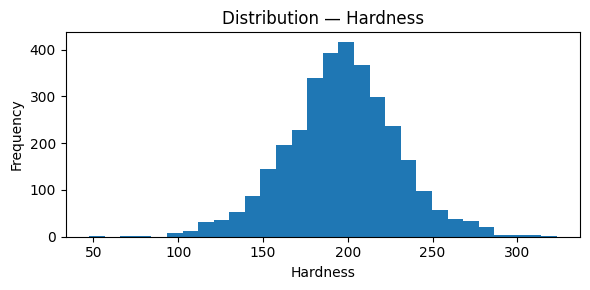

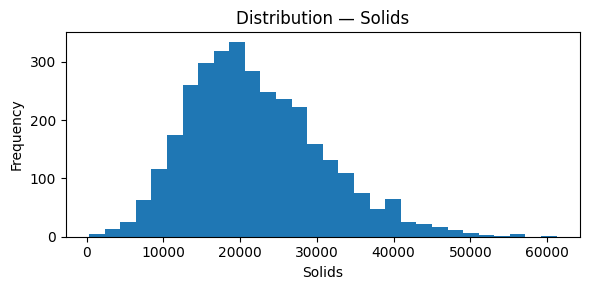

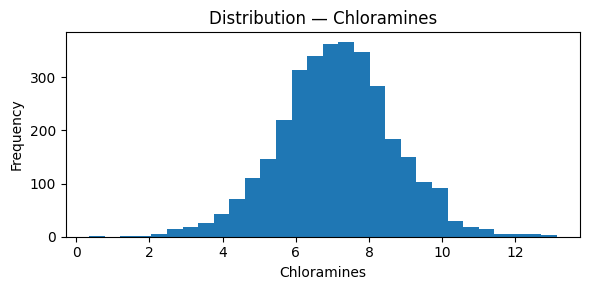

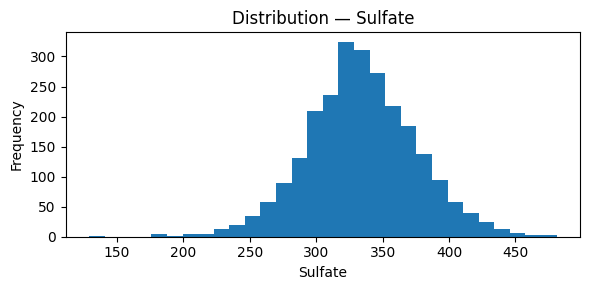

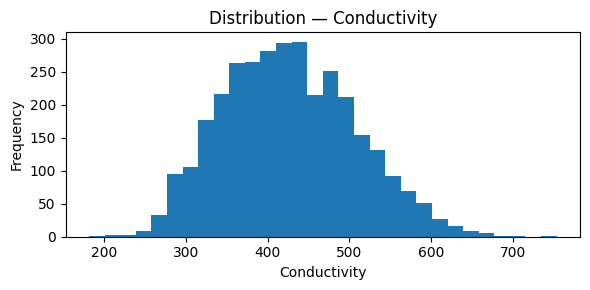

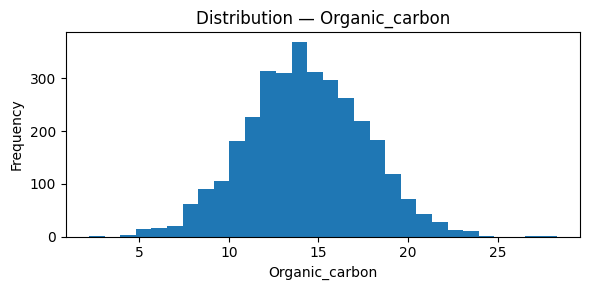

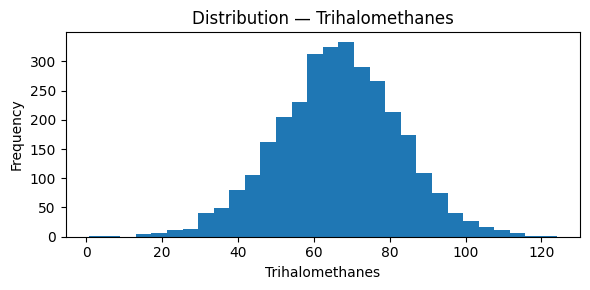

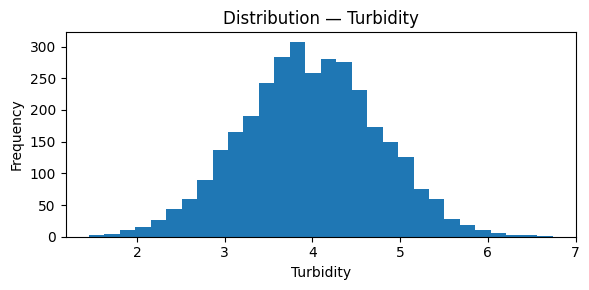

In [10]:
features=[c for c in df.columns if c!="Potability"]
for col in features:
    ax=df[col].dropna().plot.hist(bins=30,figsize=(6,3),title=f"Distribution — {col}"); ax.set_xlabel(col); plt.tight_layout(); plt.show()

## 10. Valeurs atypiques

Inspection seulement : aucune suppression automatique.

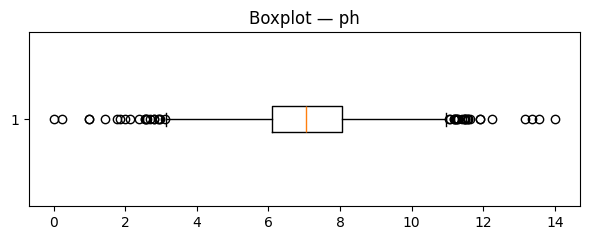

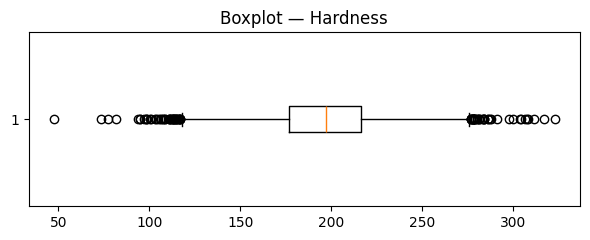

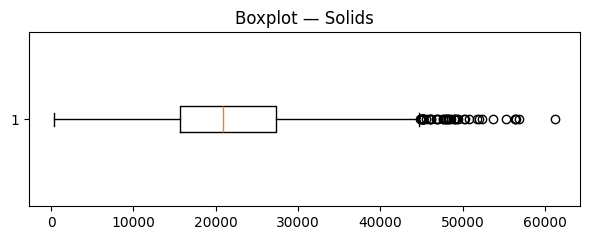

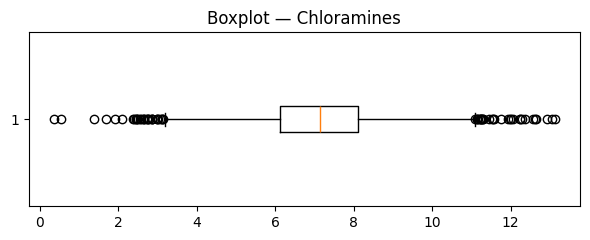

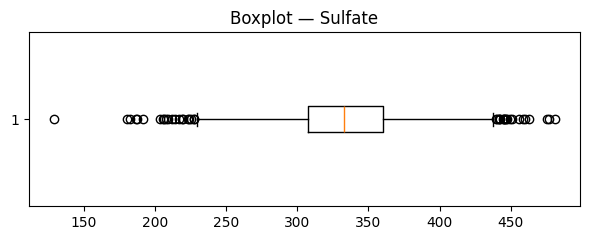

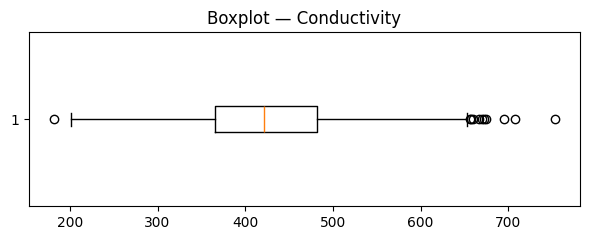

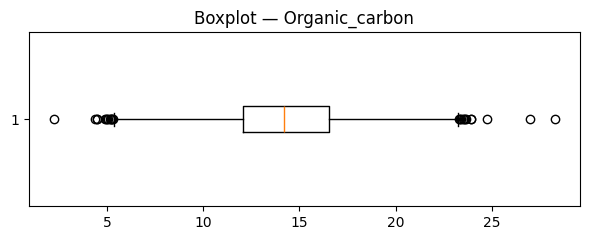

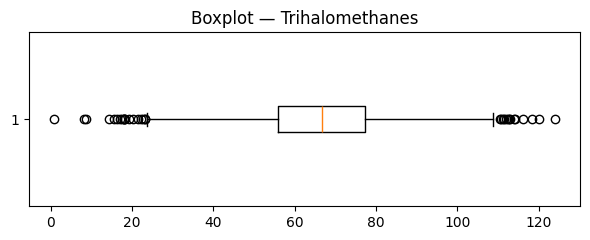

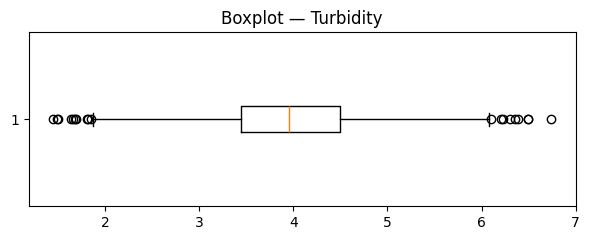

In [11]:
for col in features:
    fig,ax=plt.subplots(figsize=(6,2.5)); ax.boxplot(df[col].dropna(),vert=False); ax.set_title(f"Boxplot — {col}"); plt.tight_layout(); plt.show()

## 11. Corrélations

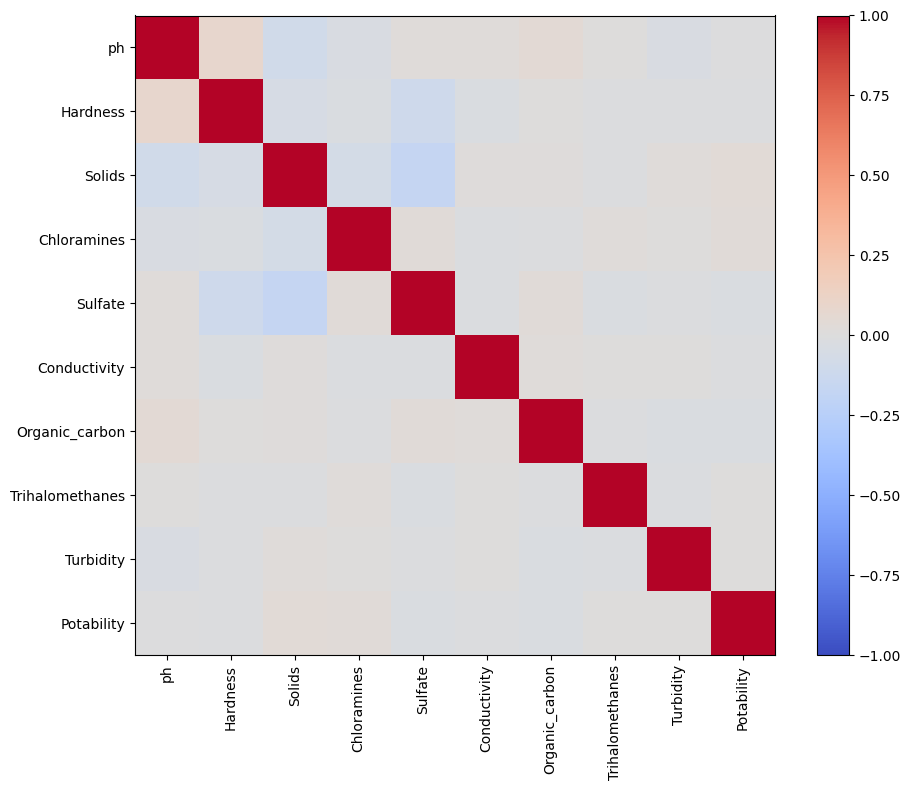

In [12]:
corr=df.corr(numeric_only=True); fig,ax=plt.subplots(figsize=(10,8)); im=ax.imshow(corr,cmap="coolwarm",vmin=-1,vmax=1); ax.set_xticks(range(len(corr)),corr.columns,rotation=90); ax.set_yticks(range(len(corr)),corr.index); fig.colorbar(im,ax=ax); plt.tight_layout(); plt.show()

## 12. Comparaison par classe

In [13]:
display(df.groupby("Potability")[features].median().T)

Potability,0,1
ph,7.035456,7.036752
Hardness,197.123423,196.632907
Solids,20809.618280,21199.386614
Chloramines,7.090334,7.215163
Sulfate,333.389426,331.838167
Conductivity,422.229331,420.712729
Organic_carbon,14.293508,14.162809
Trihalomethanes,66.542198,66.678214
Turbidity,3.948076,3.958576


## 13. Export nettoyé

In [14]:
save_processed(df,DATA_PROCESSED/"potability_clean.csv")
print("Export terminé")

Export terminé


## 14. Synthèse à rédiger

Documenter les valeurs manquantes, le déséquilibre de classes, les distributions, les corrélations et les limites du dataset.